### **PRE_ENTREGA - PROYECTO FINAL (ARTIFICIAL INTELLIGENCE I 2025-1)**


In [ ]:
# ============================================================
# PROYECTO: Prediccion de Salario en Ciencia de Datos (REGRESION)
# Notebook 100% funcional (PRE-ENTREGA)
# Dataset: DataScience_salaries
# ============================================================

# --- 1) Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [ ]:
import pandas as pd

# --- 2) Cargar dataset ---
file_id = "1z3shDrg20ddQwxnL8GULNqRQ0YU5oz8i"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

print("Cargando dataset desde Google Drive...")
df = pd.read_csv(url)
print("✅ Dataset cargado exitosamente. Filas y columnas:", df.shape)

# --- 3) Requeridos por el profesor: shape / head / describe / columns / info ---
print("SHAPE:", df.shape)

print("\nHEAD:")
display(df.head(5))

print("\nDESCRIBE:")
display(df.describe(include="all").T)

print("\nCOLUMNS:", df.columns.tolist())

print("\nINFO:")
df.info()

Cargando dataset desde Google Drive...
✅ Dataset cargado exitosamente. Filas y columnas: (14838, 11)
SHAPE: (14838, 11)

HEAD:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021,MI,FT,Data Scientist,30400000,CLP,40038,CL,100,CL,L
1,2021,MI,FT,BI Data Analyst,11000000,HUF,36259,HU,50,US,L
2,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
3,2021,MI,FT,ML Engineer,8500000,JPY,77364,JP,50,JP,S
4,2022,SE,FT,Lead Machine Learning Engineer,7500000,INR,95386,IN,50,IN,L



DESCRIBE:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,14838.0,NaN,NaN,NaN,2023.1389,0.700799,2020.0,2023.0,2023.0,2024.0,2024.0
experience_level,14838,4,SE,9696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,14838,4,FT,14772,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,14838,153,Data Engineer,3162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,14838.0,NaN,NaN,NaN,165022.718965,356235.426522,14000.0,102100.0,142200.0,187500.0,30400000.0
salary_currency,14838,23,USD,13682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,14838.0,NaN,NaN,NaN,149874.718763,69009.181349,15000.0,102000.0,141300.0,185900.0,800000.0
employee_residence,14838,88,US,12926,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,14838.0,NaN,NaN,NaN,32.76048,46.488278,0.0,0.0,0.0,100.0,100.0
company_location,14838,77,US,12975,NaN,NaN,NaN,NaN,NaN,NaN,NaN



COLUMNS: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14838 entries, 0 to 14837
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           14838 non-null  int64 
 1   experience_level    14838 non-null  object
 2   employment_type     14838 non-null  object
 3   job_title           14838 non-null  object
 4   salary              14838 non-null  int64 
 5   salary_currency     14838 non-null  object
 6   salary_in_usd       14838 non-null  int64 
 7   employee_residence  14838 non-null  object
 8   remote_ratio        14838 non-null  int64 
 9   company_location    14838 non-null  object
 10  company_size        14838 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.2+ MB


In [ ]:
# --- 4) Explicar significado de cada columna (tabla) + mini mejoras ---
import pandas as pd

pd.set_option("display.max_colwidth", None)   # ✅ evita que se corte el texto en la tabla

desc = {
    "work_year": "Año del salario",
    "experience_level": "Nivel: EN Entry, MI Mid, SE Senior, EX Executive",
    "employment_type": "Tipo empleo: FT full-time, PT part-time, CT contract, FL freelance",
    "job_title": "Cargo / Rol",
    "salary": "Salario en moneda original (NO usar para predecir salary_in_usd por leakage)",
    "salary_currency": "Moneda original (NO usar para predecir salary_in_usd por leakage)",
    "salary_in_usd": "Salario en USD (TARGET)",
    "employee_residence": "País de residencia del empleado (código)",
    "remote_ratio": "Porcentaje remoto (0/50/100)",
    "company_location": "País de la empresa (código)",
    "company_size": "Tamaño empresa (S/M/L)"
}

meaning = pd.DataFrame({
    "columna": df.columns,
    "significado": [desc.get(c, "Sin descripcion (revisar dataset)") for c in df.columns]
})

assert "salary_in_usd" in df.columns, "❌ No existe la columna target 'salary_in_usd' en el dataset"  # ✅ validación

display(meaning)

,columna,significado
0,work_year,Año del salario
1,experience_level,"Nivel: EN Entry, MI Mid, SE Senior, EX Executive"
2,employment_type,"Tipo empleo: FT full-time, PT part-time, CT contract, FL freelance"
3,job_title,Cargo / Rol
4,salary,Salario en moneda original (NO usar para predecir salary_in_usd por leakage)
5,salary_currency,Moneda original (NO usar para predecir salary_in_usd por leakage)
6,salary_in_usd,Salario en USD (TARGET)
7,employee_residence,País de residencia del empleado (código)
8,remote_ratio,Porcentaje remoto (0/50/100)
9,company_location,País de la empresa (código)


In [ ]:
# --- 5) Identificar columnas numéricas y categóricas ---
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]
print("NUMERIC:", num_cols)
print("CATEGORICAL:", cat_cols)

NUMERIC: ['work_year', 'salary', 'salary_in_usd', 'remote_ratio']
CATEGORICAL: ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']


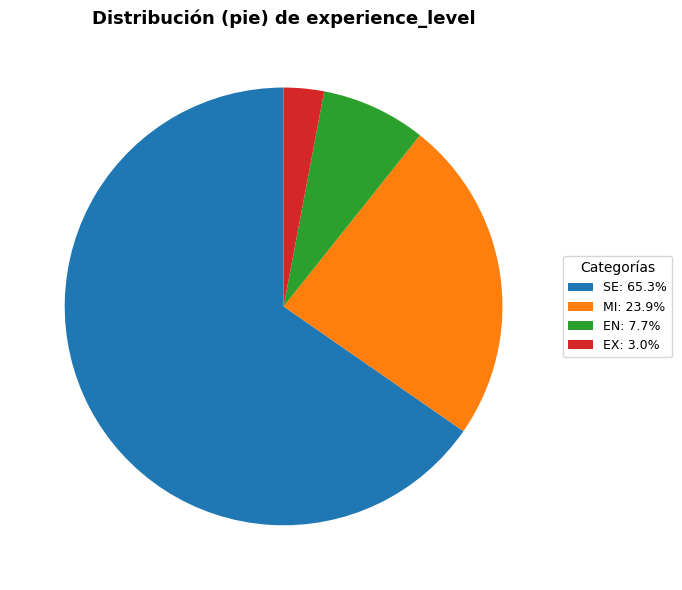


Leyenda — experience_level:
  SE: 65.3%
  MI: 23.9%
  EN: 7.7%
  EX: 3.0%


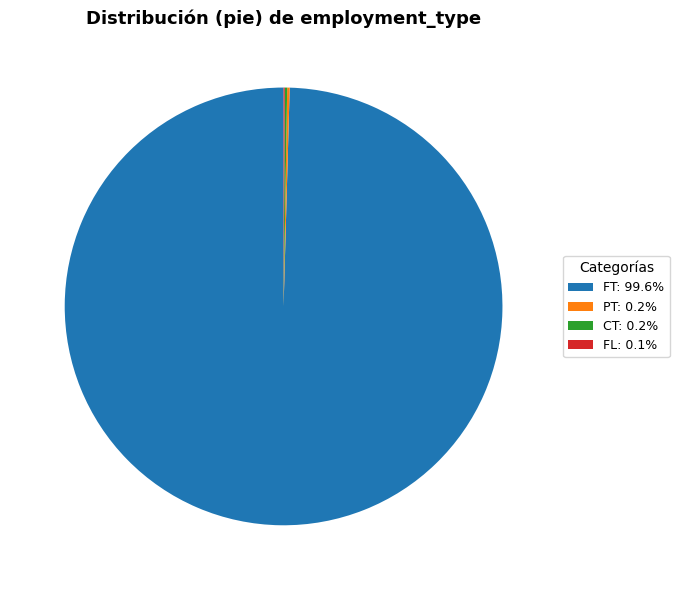


Leyenda — employment_type:
  FT: 99.6%
  PT: 0.2%
  CT: 0.2%
  FL: 0.1%


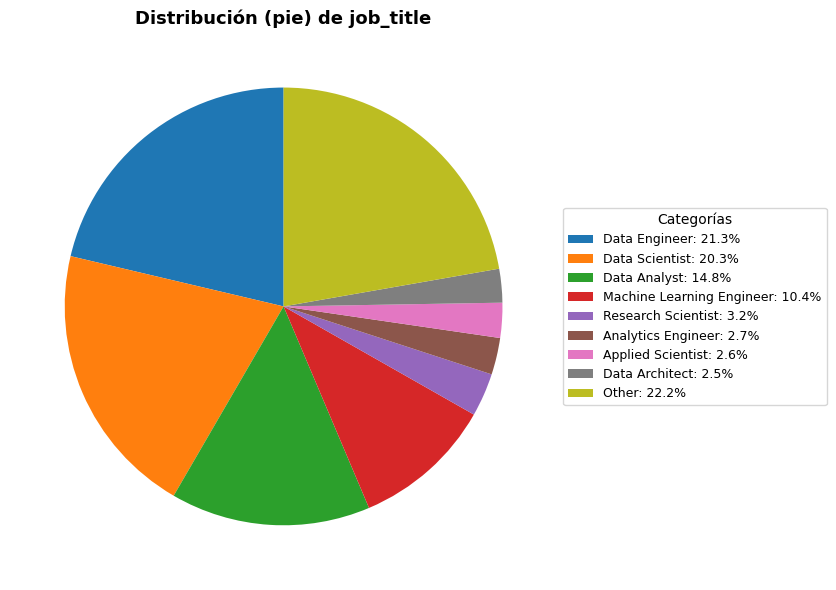


Leyenda — job_title:
  Data Engineer: 21.3%
  Data Scientist: 20.3%
  Data Analyst: 14.8%
  Machine Learning Engineer: 10.4%
  Research Scientist: 3.2%
  Analytics Engineer: 2.7%
  Applied Scientist: 2.6%
  Data Architect: 2.5%
  Other: 22.2%


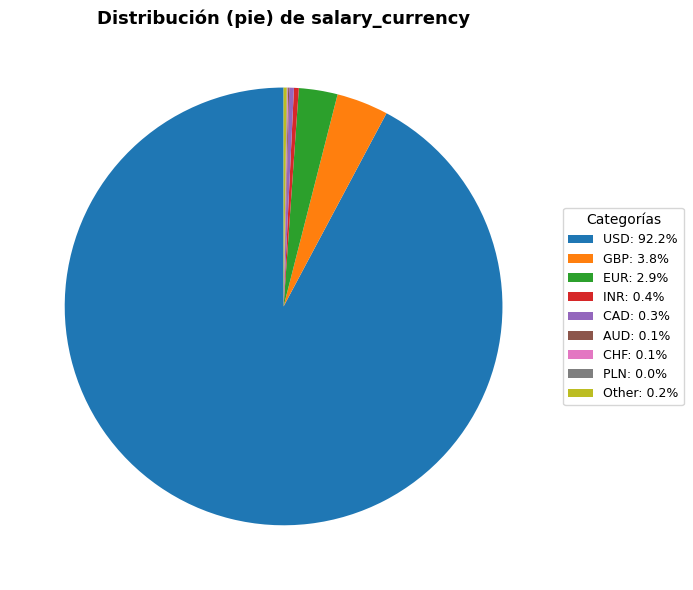


Leyenda — salary_currency:
  USD: 92.2%
  GBP: 3.8%
  EUR: 2.9%
  INR: 0.4%
  CAD: 0.3%
  AUD: 0.1%
  CHF: 0.1%
  PLN: 0.0%
  Other: 0.2%


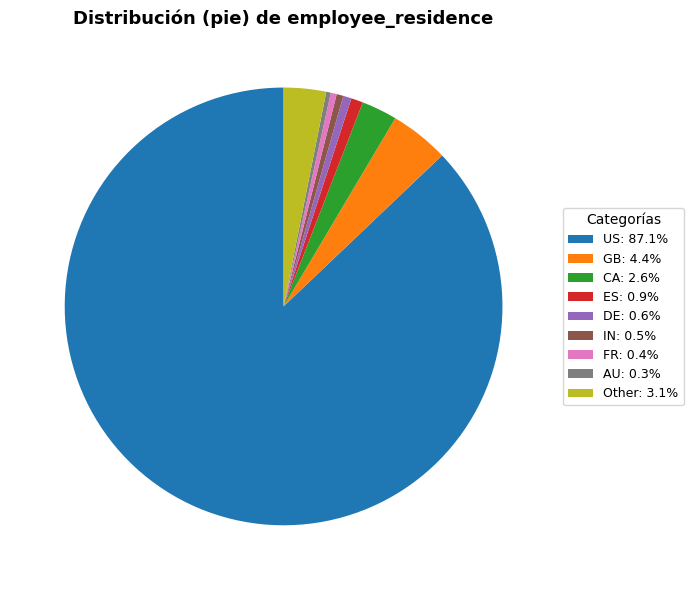


Leyenda — employee_residence:
  US: 87.1%
  GB: 4.4%
  CA: 2.6%
  ES: 0.9%
  DE: 0.6%
  IN: 0.5%
  FR: 0.4%
  AU: 0.3%
  Other: 3.1%


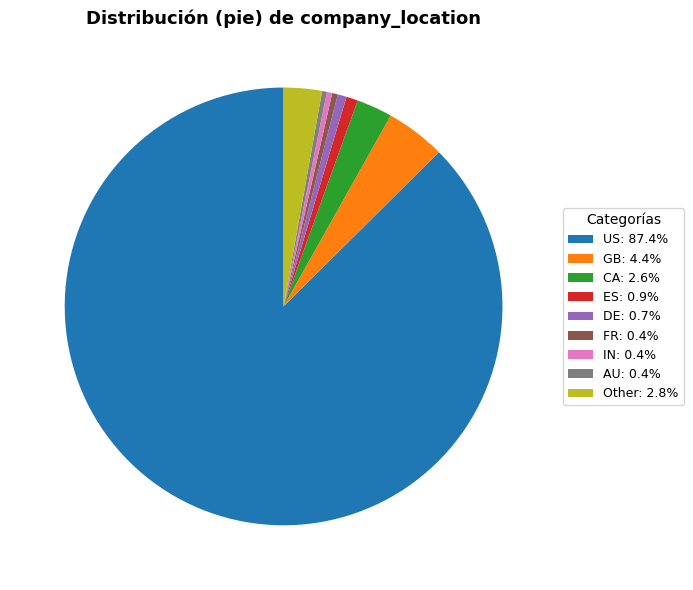


Leyenda — company_location:
  US: 87.4%
  GB: 4.4%
  CA: 2.6%
  ES: 0.9%
  DE: 0.7%
  FR: 0.4%
  IN: 0.4%
  AU: 0.4%
  Other: 2.8%


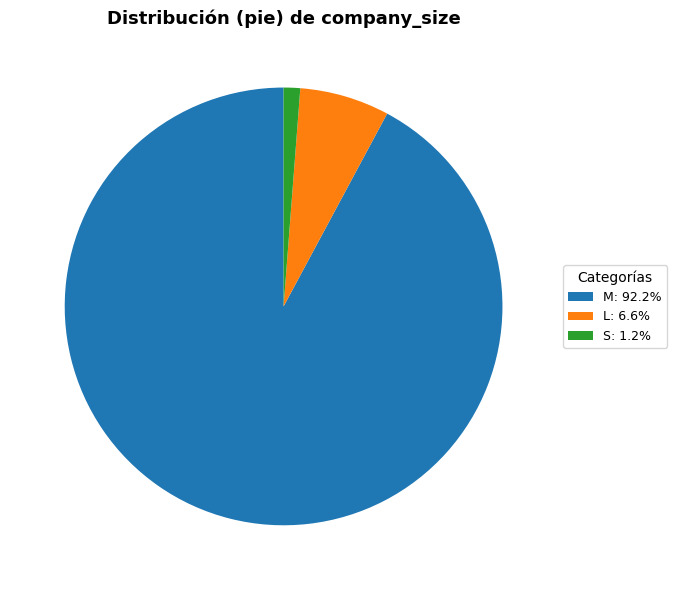


Leyenda — company_size:
  M: 92.2%
  L: 6.6%
  S: 1.2%


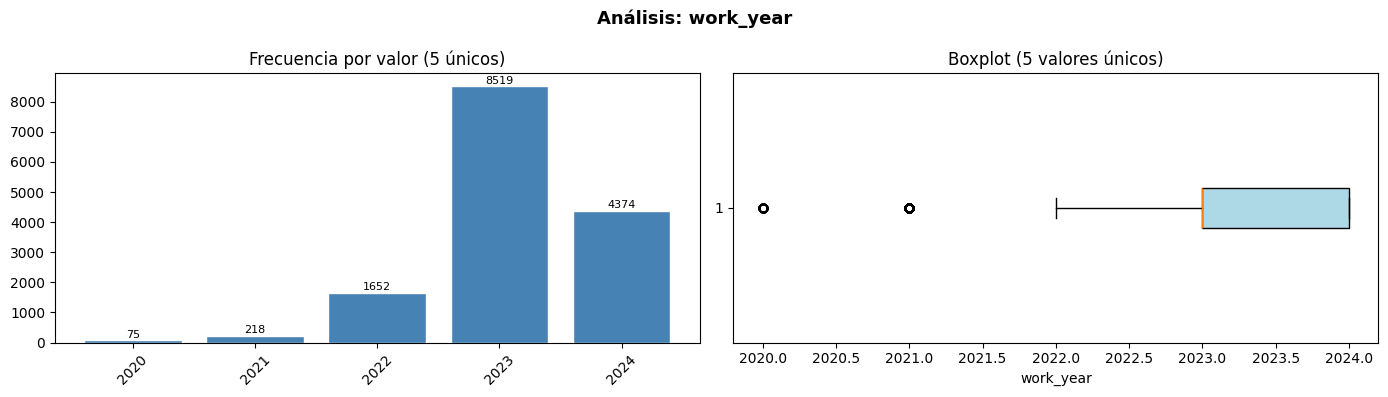


📊 work_year: min=2,020.0 | p25=2,023.0 | median=2,023.0 | p75=2,024.0 | max=2,024.0 | outliers=293 (2.0%)


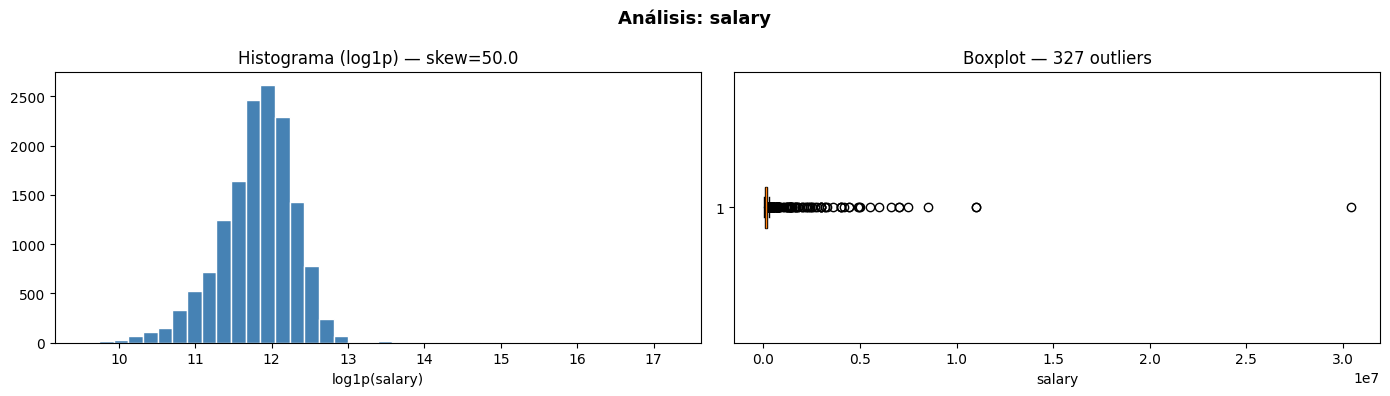


📊 salary: min=14,000.0 | p25=102,100.0 | median=142,200.0 | p75=187,500.0 | max=30,400,000.0 | outliers=327 (2.2%)


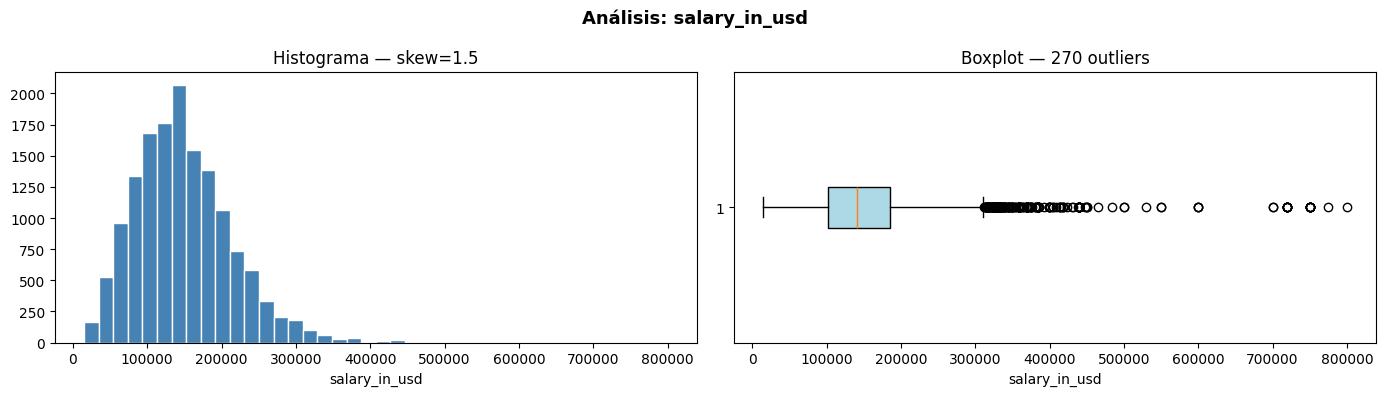


📊 salary_in_usd: min=15,000.0 | p25=102,000.0 | median=141,300.0 | p75=185,900.0 | max=800,000.0 | outliers=270 (1.8%)


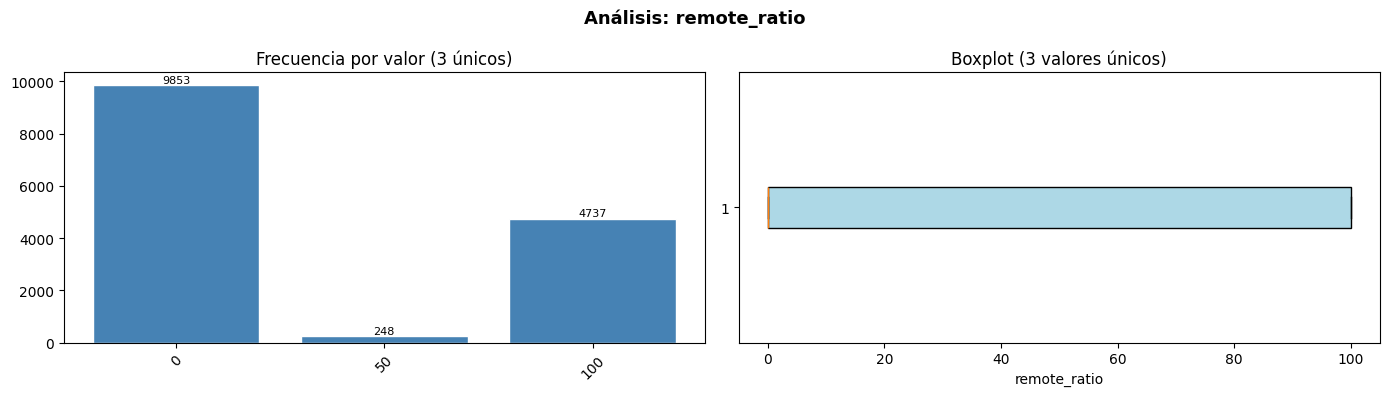


📊 remote_ratio: min=0.0 | p25=0.0 | median=0.0 | p75=100.0 | max=100.0 | outliers=0 (0.0%)


In [ ]:
# --- 6) EDA: Pie charts (categóricas) + plots inteligentes (numéricas) ---
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# CATEGÓRICAS: Pie chart limpio + leyenda lateral
# ─────────────────────────────────────────────
def pie_solo_colores_y_lista(series, title=None, top_n=8, other_name="Other", min_pct_print=0.0):
    vc = series.value_counts(dropna=False)

    if top_n is not None and len(vc) > top_n:
        vc_plot = pd.concat([vc.iloc[:top_n], pd.Series({other_name: vc.iloc[top_n:].sum()})])
    else:
        vc_plot = vc

    pct = (vc_plot / vc_plot.sum()) * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    wedges, _ = ax.pie(
        vc_plot.values,
        labels=None,
        autopct=None,
        startangle=90
    )
    ax.set_title(title or f"Distribución (pie) de {series.name}", fontsize=13, fontweight='bold')

    legend_labels = [
        f"{k}: {p:.1f}%"
        for k, p in zip(vc_plot.index.astype(str), pct.values)
        if p >= min_pct_print
    ]
    ax.legend(
        wedges[:len(legend_labels)],
        legend_labels,
        title="Categorías",
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1),
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

    print(f"\nLeyenda — {series.name}:")
    for label in legend_labels:
        print(f"  {label}")


# ─────────────────────────────────────────────
# NUMÉRICAS: Gráfica inteligente según naturaleza del dato
# ─────────────────────────────────────────────
def _count_outliers(s):
    """Cuenta outliers por método IQR."""
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()


def smart_plot_numeric(series, title=None):
    """Elige el mejor tipo de gráfica según la naturaleza del dato."""
    s = series.dropna()
    name = series.name
    n_unique = s.nunique()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title or f"Análisis: {name}", fontsize=13, fontweight='bold')

    # ── Panel izquierdo ──────────────────────────────────────
    if n_unique <= 15:
        # Variable discreta con pocos valores → barras de frecuencia
        vc = s.value_counts().sort_index()
        axes[0].bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
        axes[0].set_title(f"Frecuencia por valor ({n_unique} únicos)")
        axes[0].tick_params(axis='x', rotation=45)
        for i, v in enumerate(vc.values):
            axes[0].text(i, v + max(vc.values) * 0.01, str(v), ha='center', fontsize=8)
    else:
        # Variable continua → histograma (log si muy sesgada)
        skewness = s.skew()
        if abs(skewness) > 2:
            axes[0].hist(np.log1p(s), bins=40, color='steelblue', edgecolor='white')
            axes[0].set_title(f"Histograma (log1p) — skew={skewness:.1f}")
            axes[0].set_xlabel(f"log1p({name})")
        else:
            axes[0].hist(s, bins=40, color='steelblue', edgecolor='white')
            axes[0].set_title(f"Histograma — skew={skewness:.1f}")
            axes[0].set_xlabel(name)

    # ── Panel derecho ─────────────────────────────────────────
    n_outliers = _count_outliers(s)
    pct_outliers = n_outliers / len(s)

    if n_unique <= 15:
        # Discreta: boxplot simple
        axes[1].boxplot(s, vert=False, showfliers=True,
                        patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
        axes[1].set_title(f"Boxplot ({n_unique} valores únicos)")
    elif pct_outliers > 0.05:
        # Muchos outliers: recortar al percentil 99
        p99 = s.quantile(0.99)
        s_trim = s[s <= p99]
        axes[1].boxplot(s_trim, vert=False, showfliers=True,
                        patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
        axes[1].set_title(f"Boxplot (recortado p99={p99:,.0f}) — {n_outliers} outliers totales")
    else:
        axes[1].boxplot(s, vert=False, showfliers=True,
                        patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
        axes[1].set_title(f"Boxplot — {n_outliers} outliers")

    axes[1].set_xlabel(name)
    plt.tight_layout()
    plt.show()

    # Stats en consola
    print(f"\n📊 {name}: min={s.min():,.1f} | p25={s.quantile(.25):,.1f} | "
          f"median={s.median():,.1f} | p75={s.quantile(.75):,.1f} | "
          f"max={s.max():,.1f} | outliers={n_outliers} ({pct_outliers:.1%})")


# ─────────────────────────────────────────────
# EJECUTAR
# ─────────────────────────────────────────────
for c in cat_cols:
    pie_solo_colores_y_lista(df[c], top_n=8, title=f"Distribución (pie) de {c}")

for c in num_cols:
    smart_plot_numeric(df[c])

In [ ]:
# --- 7) Outliers con IQR (requerido) ---
def iqr_bounds(s, k=1.5):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return q1, q3, iqr, lo, hi

iqr_report = []
for c in num_cols:
    s = df[c].dropna()
    if len(s) == 0:
        continue
    q1, q3, iqr, lo, hi = iqr_bounds(s)
    out = ((s < lo) | (s > hi)).sum()
    iqr_report.append([c, q1, q3, iqr, lo, hi, out, out/len(s)])

iqr_df = pd.DataFrame(
    iqr_report,
    columns=["col", "Q1", "Q3", "IQR", "lower", "upper", "#outliers", "%outliers"]
).sort_values("%outliers", ascending=False)

display(iqr_df)


,col,Q1,Q3,IQR,lower,upper,#outliers,%outliers
1,salary,102100.0,187500.0,85400.0,-26000.0,315600.0,327,0.022038
0,work_year,2023.0,2024.0,1.0,2021.5,2025.5,293,0.019747
2,salary_in_usd,102000.0,185900.0,83900.0,-23850.0,311750.0,270,0.018197
3,remote_ratio,0.0,100.0,100.0,-150.0,250.0,0,0.000000
